In [12]:
# импорт библиотек

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plp

In [13]:
# загрузка данных

heart_desise = pd.read_csv('/Users/konstantingeneralov/IDE/Data/DL_PJ_train.csv', sep=',')
h_d = heart_desise.copy()

summary = pd.DataFrame({
    'missing': h_d.isnull().sum(),
    'duplicate': h_d.duplicated().sum(),
    'unique': h_d.nunique(),
    'type': h_d.dtypes
})
print('h_d', summary)

display(heart_desise.head(), heart_desise.info(), heart_desise.describe())

h_d                                       missing  duplicate  unique     type
ID                                          0          0  600000    int64
age                                         0          0  594106  float64
sex                                         0          0       2    int64
chest                                       0          0  133009  float64
resting_blood_pressure                      0          0  596241  float64
serum_cholestoral                           0          0  598797  float64
fasting_blood_sugar                         0          0       2    int64
resting_electrocardiographic_results        0          0       3    int64
maximum_heart_rate_achieved                 0          0  597583  float64
exercise_induced_angina                     0          0       2    int64
oldpeak                                     0          0  384255  float64
slope                                       0          0       3    int64
number_of_major_vessels           

,ID,age,sex,chest,resting_blood_pressure,serum_cholestoral,fasting_blood_sugar,resting_electrocardiographic_results,maximum_heart_rate_achieved,exercise_induced_angina,oldpeak,slope,number_of_major_vessels,thal,class
0,0,49.207124,0,4.000000,162.996167,181.108682,0,0,148.227858,1,0.944547,2,0,3,1
1,1,53.628425,1,1.741596,130.233730,276.474630,0,2,152.917139,0,0.119070,2,0,3,0
2,2,49.591426,1,4.000000,146.999012,223.300517,1,2,102.352090,1,1.616747,2,2,7,1
3,3,58.991445,1,4.000000,112.369143,187.245501,0,0,158.164750,1,0.000000,1,1,7,1
4,4,51.053602,1,1.954609,138.032047,238.482868,0,0,172.540828,0,1.150464,1,1,3,0


None

,ID,age,sex,chest,resting_blood_pressure,serum_cholestoral,fasting_blood_sugar,resting_electrocardiographic_results,maximum_heart_rate_achieved,exercise_induced_angina,oldpeak,slope,number_of_major_vessels,thal,class
count,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000,600000.000000
mean,299999.500000,54.426085,0.677447,3.170247,131.340485,249.592420,0.150757,1.020148,149.592069,0.333502,1.051391,1.596033,0.681303,4.711378,0.444185
std,173205.225094,9.086041,0.467454,0.949618,17.842450,51.699976,0.357812,0.994204,23.072593,0.471464,1.144288,0.629821,0.950669,1.934766,0.496875
min,0.000000,26.061695,0.000000,-0.538498,82.918527,98.326263,0.000000,0.000000,61.844168,0.000000,-0.806788,1.000000,0.000000,3.000000,0.000000
25%,149999.750000,48.078493,0.000000,3.000000,119.924094,216.475964,0.000000,0.000000,135.704237,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,299999.500000,55.133425,1.000000,3.000000,129.727941,244.233699,0.000000,2.000000,153.224828,0.000000,0.811101,2.000000,0.000000,3.000000,0.000000
75%,449999.250000,60.663775,1.000000,4.000000,139.915216,274.345453,0.000000,2.000000,165.165497,1.000000,1.674081,2.000000,1.000000,7.000000,1.000000
max,599999.000000,79.591647,1.000000,4.000000,209.673650,527.755764,1.000000,2.000000,208.735196,1.000000,6.803372,3.000000,3.000000,7.000000,1.000000


## Оптсание данных
при первом взгляде на данные видно 15 колонок и 600000 строк
 - есть непрерывные числовые колонки age, resting_blood_pressure, serum_cholestoral, maximum_heart_rate_achieved, `oldpeak`

In [93]:
# 1. Посчитайте количество мужчин и женщин в датасете и их возрастные характеристики. Сравните их между собой.

h_d['age']=h_d['age'].astype(int)

agg = pd.DataFrame({
    'age': h_d['age'].value_counts()
})

summary = pd.DataFrame({
    'missing': h_d.isnull().sum(),
    'duplicaped': h_d.duplicated().sum(),
    'unique': h_d.nunique(),
    'type': h_d.dtypes
    })

summary

s = pd.pivot_table(
    h_d,
    index=['age','sex'],
    columns=['class'],
    values=['resting_blood_pressure', 'serum_cholestoral', 'fasting_blood_sugar'],
    aggfunc='mean'
)
display(s.head())
#agg

fasting_blood_sugar      resting_blood_pressure              \
class                     0    1                      0           1   
age sex                                                               
26  0              0.000000  NaN             141.855605         NaN   
27  0              0.000000  NaN             137.064190         NaN   
    1              0.000000  NaN             130.573153         NaN   
28  0              0.000000  0.0             154.862258  131.146657   
    1              0.166667  0.0             126.874270  109.234861   

        serum_cholestoral              
class                   0           1  
age sex                                
26  0          236.184814         NaN  
27  0          228.892750         NaN  
    1          213.278181         NaN  
28  0          226.037772  260.061076  
    1          242.421320  276.803021

In [101]:
data = [1, 2, 2, 3, 4, 4, 4, 5]
data_1 = []

# перебрать все и записать только уникальные 
for i in data:
    if i not in data_1:
        data_1.append(i)

# подсчитать кол-во каждого элемента
for i in data_1:
    count = data.count(i)
    print(f"Элемент {i} встречается {count} раз(а)")

print(data_1)

data_pd= pd.Series(data)
# подсчитать кол-во уникальных
fr = pd.DataFrame({
    'fr': data_pd.value_counts()
})

fr_2 = data_pd.value_counts()
fr_2 = fr_2.reset_index()
fr_2.columns = ['elem', 'count']

display(fr, fr.max(), fr_2)


Элемент 1 встречается 1 раз(а)
Элемент 2 встречается 2 раз(а)
Элемент 3 встречается 1 раз(а)
Элемент 4 встречается 3 раз(а)
Элемент 5 встречается 1 раз(а)
[1, 2, 3, 4, 5]


,fr
4,3
2,2
1,1
3,1
5,1


fr    3
dtype: int64

,elem,count
0,4,3
1,2,2
2,1,1
3,3,1
4,5,1


In [70]:
df = pd.DataFrame({
    'name': ['Alice', 'Bob', 'Charlie', 'David', 'Eva'],
    'age': [25, 30, 35, None, 40],
    'salary': [50000, 60000, None, 80000, 90000],
    'city': ['NY', 'LA', 'NY', 'LA', 'NY']
})

display(df.head(),df.info())

df_bonus = pd.DataFrame({
    'name': ['Alice', 'Bob', 'Eva'],
    'bonus': [5000, 7000, 10000]
})

summary = pd.DataFrame({
    'missing': df.isnull().sum(),
    'duplicated': df.duplicated().sum(),
    'unique': df.nunique(),
    'type': df.dtypes
    })

summary


<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   name    5 non-null      str    
 1   age     4 non-null      float64
 2   salary  4 non-null      float64
 3   city    5 non-null      str    
dtypes: float64(2), str(2)
memory usage: 292.0 bytes


,name,age,salary,city
0,Alice,25.0,50000.0,NY
1,Bob,30.0,60000.0,LA
2,Charlie,35.0,NaN,NY
3,David,NaN,80000.0,LA
4,Eva,40.0,90000.0,NY


None

,missing,duplicated,unique,type
name,0,0,5,str
age,1,0,4,float64
salary,1,0,4,float64
city,0,0,2,str


In [73]:
df['age'] = df['age'].fillna(df['age'].mean())
df['salary'] = df['salary'].fillna(df['salary'].median())

display(df.head(), df.info(), df.describe(include='all'))

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   name    5 non-null      str    
 1   age     5 non-null      float64
 2   salary  5 non-null      float64
 3   city    5 non-null      str    
dtypes: float64(2), str(2)
memory usage: 292.0 bytes


,name,age,salary,city
0,Alice,25.0,50000.0,NY
1,Bob,30.0,60000.0,LA
2,Charlie,35.0,70000.0,NY
3,David,32.5,80000.0,LA
4,Eva,40.0,90000.0,NY


None

,name,age,salary,city
count,5,5.00000,5.000000,5
unique,5,NaN,NaN,2
top,Alice,NaN,NaN,NY
freq,1,NaN,NaN,3
mean,NaN,32.50000,70000.000000,NaN
std,NaN,5.59017,15811.388301,NaN
min,NaN,25.00000,50000.000000,NaN
25%,NaN,30.00000,60000.000000,NaN
50%,NaN,32.50000,70000.000000,NaN
75%,NaN,35.00000,80000.000000,NaN


In [ ]:
# с помощью query Людей старше 30,Людей из NY с зарплатой > 60000
a = df.query('age > 30')
b = df.query('city == "NY" & salary > 60000')
display(a, b)

,name,age,salary,city
2,Charlie,35.0,70000.0,NY
3,David,32.5,80000.0,LA
4,Eva,40.0,90000.0,NY


,name,age,salary,city
2,Charlie,35.0,70000.0,NY
4,Eva,40.0,90000.0,NY


In [ ]:
groupps_1 = df.groupby('city').agg({'salary': 'mean', 'age': 'mean', 'name': 'count'})
display(groupps_1)

,city,salary,age,name
0,LA,70000.0,31.250000,2
1,NY,70000.0,33.333333,3


In [82]:
new_df = df.merge(df_bonus, on='name', how='left')
new_df['bonus'] = new_df['bonus'].fillna(0)
new_df

,name,age,salary,city,bonus
0,Alice,25.0,50000.0,NY,5000.0
1,Bob,30.0,60000.0,LA,7000.0
2,Charlie,35.0,70000.0,NY,0.0
3,David,32.5,80000.0,LA,0.0
4,Eva,40.0,90000.0,NY,10000.0


In [83]:
pd.pivot_table(new_df, index='city', values=['salary', 'bonus'], aggfunc='mean')

,bonus,salary
city,,
LA,3500.0,70000.0
NY,5000.0,70000.0


In [103]:
new_df.sort_values(by=['salary','age'], ascending=False)

,name,age,salary,city,bonus
4,Eva,40.0,90000.0,NY,10000.0
3,David,32.5,80000.0,LA,0.0
2,Charlie,35.0,70000.0,NY,0.0
1,Bob,30.0,60000.0,LA,7000.0
0,Alice,25.0,50000.0,NY,5000.0


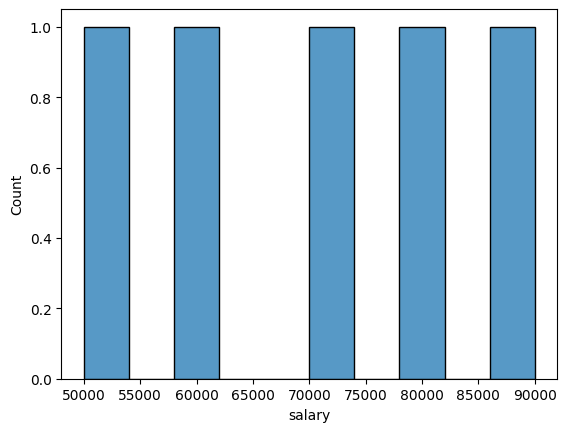

<Axes: xlabel='city', ylabel='salary'>

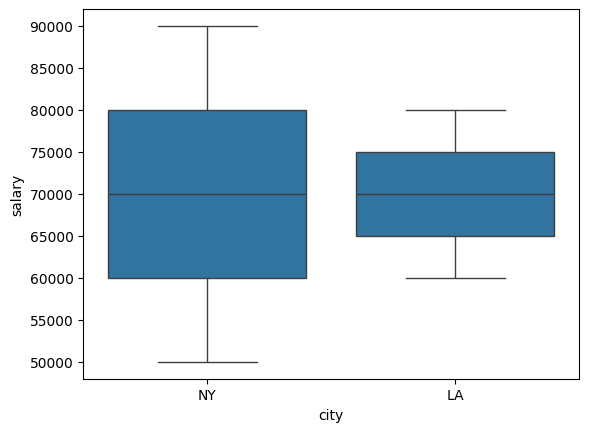

In [109]:
# гистограмма зарплат
sns.histplot(data=new_df, x='salary',bins=10)
plp.show()

sns.boxplot(data=new_df, x='city', y='salary')



<Axes: xlabel='age', ylabel='salary'>

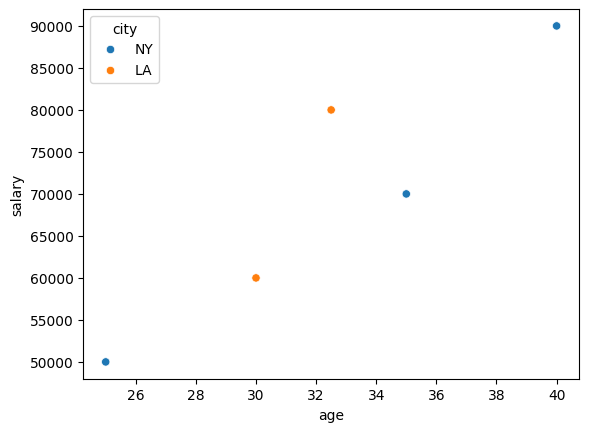

In [111]:
sns.scatterplot(data=new_df, x='age', y='salary', hue='city')

In [117]:

def normalize(lst):
    min_val = min(lst)
    max_val = max(lst)
    return [(x - min_val) / (max_val - min_val) for x in lst] if max_val != min_val else [0 for _ in lst]
# проверка функции
data = [10, 20, 30, 40, 50, 89]
normalized_data = normalize(data)
print(normalized_data)

# давай через pandas
data_pd = pd.Series(data)
normalized_data_pd = (data_pd - data_pd.min()) / (data_pd.max() - data_pd.min())
print(normalized_data_pd.tolist())  

#  в пандасе есть функция для нормализации MinMaxScaler из sklearn
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
normalized_data_sklearn = scaler.fit_transform(data_pd.values.reshape(-1, 1)).flatten()
print(normalized_data_sklearn.tolist())


[0.0, 0.12658227848101267, 0.25316455696202533, 0.379746835443038, 0.5063291139240507, 1.0]
[0.0, 0.12658227848101267, 0.25316455696202533, 0.379746835443038, 0.5063291139240507, 1.0]
[0.0, 0.12658227848101267, 0.2531645569620253, 0.379746835443038, 0.5063291139240507, 1.0]
